In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [14]:
# Load dataset
df = pd.read_csv("EFIplus_medit.csv", sep=';')

# Show first 5 rows
df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [15]:
print(df.columns)

Index(['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name',
       'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect',
       'Calib_hydrol',
       ...
       'Squalius malacitanus', 'Squalius pyrenaicus', 'Squalius torgalensis',
       'Thymallus thymallus', 'Tinca tinca', 'Zingel asper', 'Squalius sp',
       'Barbatula sp', 'Phoxinus sp', 'Iberochondrostoma_sp'],
      dtype='object', length=164)


In [16]:
# Find the 4 catchments with most sampling sites
top_catchments = df['Catchment_name'].value_counts().head(4)

# Display results
print(top_catchments)

Catchment_name
Ebro            736
Galiza-Norte    709
Minho           707
Tejo            509
Name: count, dtype: int64


In [17]:
# Store the names of the top 4 catchments
top4 = top_catchments.index

print(top4)

Index(['Ebro', 'Galiza-Norte', 'Minho', 'Tejo'], dtype='object', name='Catchment_name')


In [18]:
# Store the names of the top 4 catchments
top4 = top_catchments.index

print(top4)

Index(['Ebro', 'Galiza-Norte', 'Minho', 'Tejo'], dtype='object', name='Catchment_name')


In [19]:
# Filter dataset for the top 4 catchments
filtered_df = df[df['Catchment_name'].isin(top4)]

# Preview filtered data
filtered_df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
5,ES_02_0005,40.732830,-2.078003,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


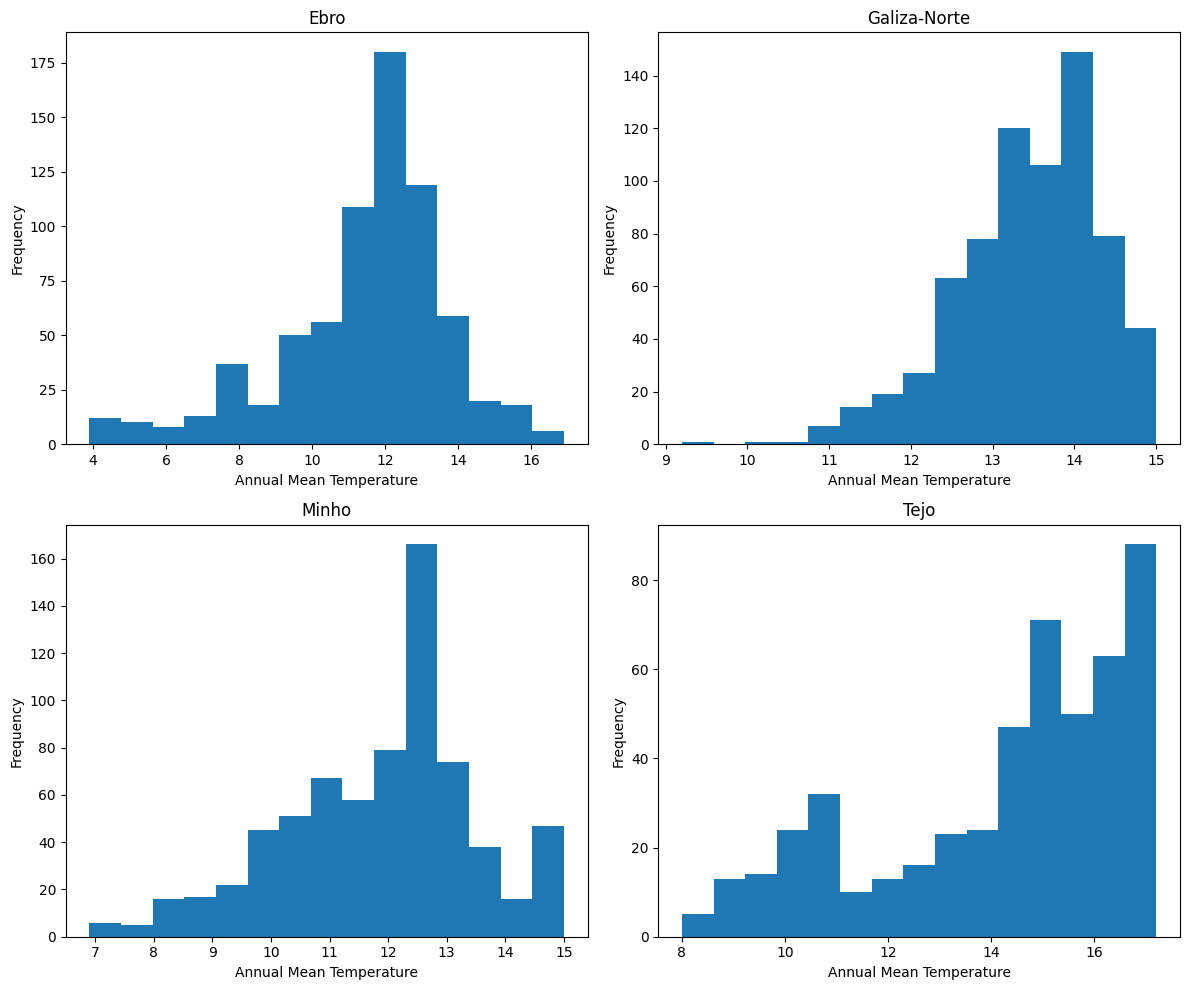

In [20]:
# Create histogram plots

fig, axes = plt.subplots(2, 2, figsize=(12,10))

for ax, catchment in zip(axes.flatten(), top4):

    subset = filtered_df[filtered_df['Catchment_name'] == catchment]

    ax.hist(subset['temp_ann'], bins=15)

    ax.set_title(catchment)
    ax.set_xlabel("Annual Mean Temperature")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Histogram Analysis

Histograms are useful for understanding the distribution of annual mean temperature values.

Advantages:
- Easy to identify distribution shape
- Good for large datasets
- Useful for detecting concentration of values

Disadvantages:
- Sensitive to bin size
- Does not show exact individual observations

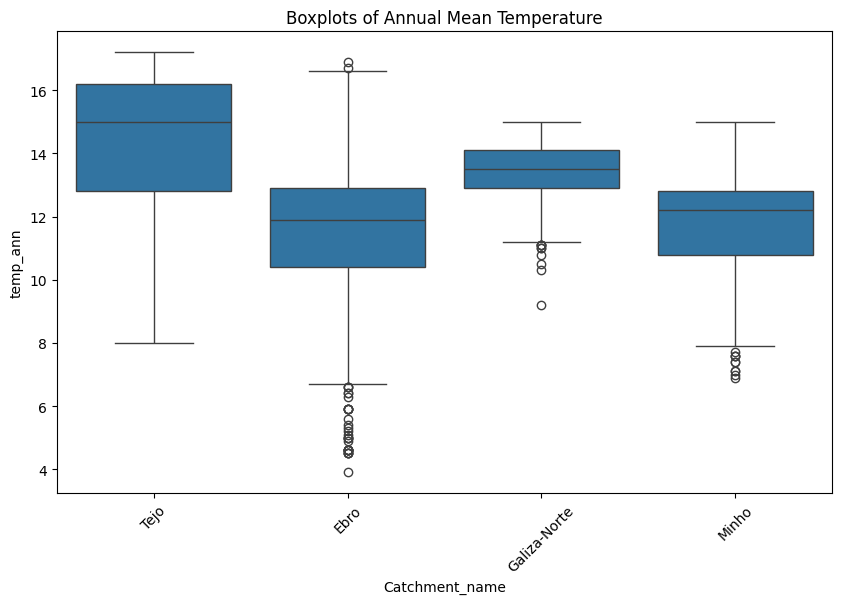

In [21]:
# Create boxplots

plt.figure(figsize=(10,6))

sns.boxplot(
    data=filtered_df,
    x='Catchment_name',
    y='temp_ann'
)

plt.title("Boxplots of Annual Mean Temperature")

plt.xticks(rotation=45)

plt.show()

# Boxplot Analysis

Boxplots summarize distributions using quartiles, medians, and outliers.

Advantages:
- Easy comparison between groups
- Good identification of outliers
- Compact summary of data

Disadvantages:
- Does not show detailed distribution shape
- Some information may be hidden

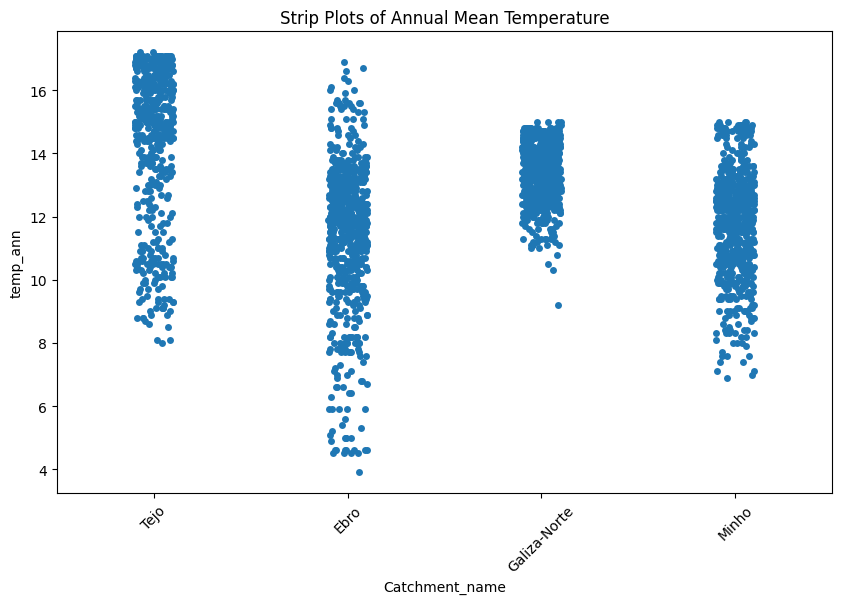

In [22]:
# Create strip plots

plt.figure(figsize=(10,6))

sns.stripplot(
    data=filtered_df,
    x='Catchment_name',
    y='temp_ann',
    jitter=True
)

plt.title("Strip Plots of Annual Mean Temperature")

plt.xticks(rotation=45)

plt.show()

# Strip Plot Analysis

Strip plots display all individual observations.

Advantages:
- Shows every data point
- Useful for detecting spread and clustering

Disadvantages:
- Can become cluttered with large datasets
- Harder to interpret dense observations

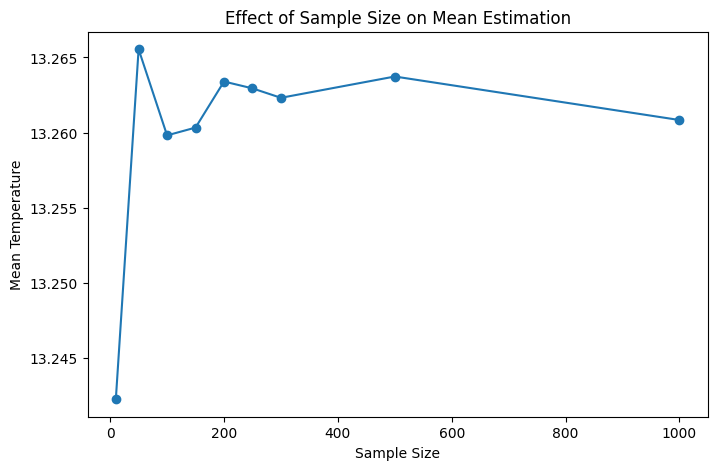

In [23]:
# Sample sizes
sample_sizes = [10, 50, 100, 150, 200, 250, 300, 500, 1000]

# Store mean results
means = []

# Repeat sampling process
for size in sample_sizes:

    sample_means = []

    for i in range(1000):

        sample = df['temp_ann'].sample(
            n=size,
            replace=True
        )

        sample_means.append(sample.mean())

    means.append(np.mean(sample_means))

# Plot results
plt.figure(figsize=(8,5))

plt.plot(sample_sizes, means, marker='o')

plt.xlabel("Sample Size")
plt.ylabel("Mean Temperature")

plt.title("Effect of Sample Size on Mean Estimation")

plt.show()

# Random Sampling Interpretation

As sample size increases, the estimated mean temperature becomes more stable and closer to the population mean.

This demonstrates that larger samples generally produce more reliable statistical estimates.